#Basic Concepts

##Discount Rewards
例子：

Professor会拿到它的薪水(Rewards), \$160K per year. 那么他一共会拿到多少薪水？

我们可以单纯的将160相加得出结论，但是现实生活可能会更加复杂。比如教授可以加薪，也可能降薪或者辞职。这样，事情变得复杂起来了

###Discount Factor
由于future reward是不确定的，所以我们要给他加一个Discount Factor $\gamma$. 同时，这也是为了要让我们的total reward converge. 否则：

**Assume**: a robot will get 160 rewards per year. Then how many total reward he get? $$160 + 160 + ... = \infty$$
What if we set a **discount factor** $\gamma = 0.9$?
$$\text{Total Rewards} = 160 + 160 \times 0.9^{1} + 160 \times 0.9^{2} + ... = 1600$$

因此，我们使用**Discounted sum of future Rewards**来表示Total Reward: \begin{align}\text{Total Rewards} =& (\text{reward now})  
 + γ(\text{reward in 1 time step from now}) \\
 +& γ^{2}(\text{reward in 2 time step from now}) \\
 +& γ^{3}(\text{reward in 3 time step from now}) \\ +& ...\end{align}

##Example
有时候，我们的state会比较复杂 (i.e. non deterministic)，我们需要通过计算Expect Reward/Value来确定哪一步是最好的行动。但是计算Expect Reward/Value并不容易。下面便是一个例子：

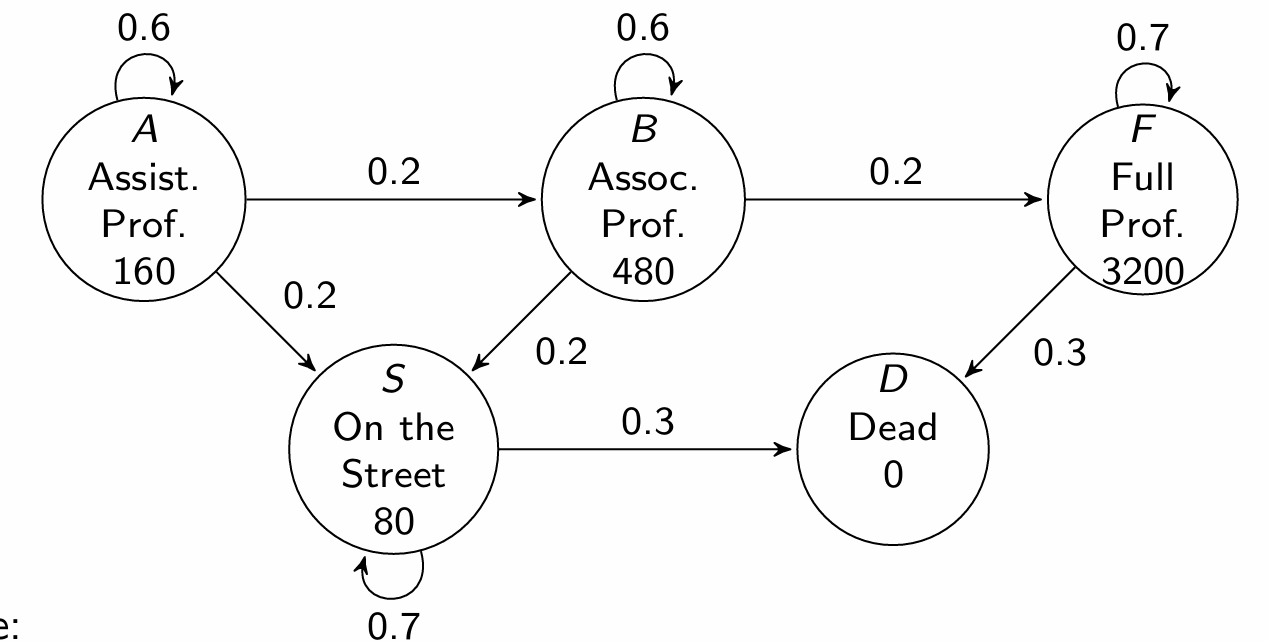

在上图中，箭头上的数字表示从一个state转移到另一个state的概率(这两个state允许相同)。圆圈中的数字表示我们的Reward/Value.

Now, we want to calculate $V_{A}$, which is **the Expected discounted sum of future rewards starting in state A**. How to do this?

###Idea
- Let $V_{A}^{1}$, $V_{B}^{1}$, $V_{F}^{1}$, $V_{S}^{1}$, $V_{D}^{1}$ be **the expected discounted sum of rewards over the next 1 time step from now**.
- Let $V_{A}^{2}$ be **the expected discounted sum of rewards over the next 2 time step from now**.
- Calculate $V_{X}^{1}$, where $X = \{A, B, F, S, D\}$. Then based on the result of $V_{X}^{1}$, calculate $V_{A}^{2}$

###Implement
显然，这里的**next 1 step**意味着我们只是先"进入"了一个state, 但还没有移动，因此：
\begin{align}
V_{A}^{1} = 160, V_{B}^{1}= 480, V_{F}^{1}= 3200, V_{S}^{1}= 80,V_{D}^{1} = 0
\end{align}
然后，基于我们刚才的计算得出$V_{A}^{2}$。注意：这里$P_{AS}$表示从state A到state S的概率，即0.2
\begin{align}
V_{A}^{2} &= 160+0.9×(P_{AA}V_{A}^{1} + P_{AB}V_{B}^{1} + P_{AF}V_{F}^{1} + P_{AS}V_{S}^{1} + P_{AD}V_{D}^{1})\\
&= 160+0.9×(0.6(160)+0.2(480)+0(3200) +0.2(80) +0(0)) \\ &= 347.2
\end{align}

##Markov Property
定义：A state St is Markov if and only if
 $$P(S_{t+1}|S_{t}) = P(S_{t+1}|S_{1},...,S_{t})$$
Remark:
1. The **future is independent of the past given the present**
2. The **present state captures all relevant information from the history**
3. Once the present state is known, the history may be thrown away

##Markov System
A Markov system consists of the following:
1. A **set of N states** $\{s_{1},s_{2},...,s_{N}\}$
2. A **transition probability matrix** (i.e., a 2D array showing the probability of going from one state to another state):
$$T = \left(\begin{matrix}T_{11} &T_{12} &... &T_{1N} \\ T_{21} &T_{22} &··· &T_{2N} \\ &... \\ T_{N1} &T_{N2} &··· &T_{NN}
\end{matrix}\right)$$
这里 $T_{ij} = P(\text{next state is }s_{j}|\text{ current state is }s_{i})$ (i.e. $T_{24}$表示从state 2到state 4). 并且矩阵$T$每一横行的系数和是1
3. Each state has a **reward** $\{r_1,r_2,...,r_N\}$, and there is a **discount factor** $γ$, where $0 < γ < 1$

故我们上述的例子可以变为如下的一个markov system:
- States: $\{A, B, F, S, D\}$
- Transition probability matrix:
$$T = \left(\begin{matrix} 0.6 &0.2 &0 &0.2 &0 \\  0 &0.6 &0.2 &0.2 &0 \\ 0 &0 &0.7 &0 &0.3 \\ 0 &0 &0 &0.7 &0.3 \\ 0 &0 &0 &0 &0
\end{matrix}\right)$$
- Rewards: $\{160,480,3200,80,0\}$
- Discount Fatcor $\gamma = 0.9$

##Value Function
Let $V(s_i) = \text{expected discounted sum of future rewards starting in state }s_i$

So, we have:
\begin{align}
V(s_i) &= r(s_i) + γ·\text{Expected future rewards starting from next state }s_i \\
 &= r(s_i) + γ·(T_{i1}V(s_1)+T_{i2}V(s_2)+...+T_{iN}V(S_N))
\end{align}

使用矩阵表示，我们得到：
$$\begin{bmatrix}V_{s_{1}} \\ V_{s_{2}} \\ ... \\ V_{s_{N}}  \end{bmatrix} = \begin{bmatrix}r_1 \\ r_2 \\ ... \\ r_N  \end{bmatrix} + \gamma \left[\begin{matrix}T_{11} &T_{12} &... &T_{1N} \\ T_{21} &T_{22} &··· &T_{2N} \\ &... \\ T_{N1} &T_{N2} &··· &T_{NN} \end{matrix}\right] \begin{bmatrix}V_{s_{1}} \\ V_{s_{2}} \\ ... \\ V_{s_{N}}  \end{bmatrix}$$

这是一个linear equation, 我们可以选择直接解出精确解:
\begin{align}
V &= R + \gamma TV \\
(1 - \gamma T)V &= R \\
V &= (1 - \gamma T)^{-1}R
\end{align}
但是值得注意的是，解出这个矩阵$V$的算法复杂度为$O(n^{2})$。 如果我们想做一些性能优化，我们可能需要以下方法：
- **Dynamic programming** (We will do **Value Iteration**)
- **Monte-Carlo evaluation**
- Temporal-Difference learning

## Value Iteration
定义：
$$V^{k}(s_i) = \text{Expected discounted sum of rewards over the next k time steps from now}$$
则，我们可以使用如下的formula (**recurrence relation**)来计算Expected Value:
$$V^{k}(s_i) = r(s_i) + γ(T_{i1}V^{k−1}(s_1) + T_{i2}V^{k−1}(s_2) + ... + T_{iN}V^{k−1}(s_N))$$

#Markov Decision Process Formulation

###Nondeterministic Actions
在现实生活中，可能并不是所有事情都是deterministic的，所以我们要考虑接下来发生各个state的probability.

例子：You can take a taxi to the airport which takes 40 minutes normally 90% and costs \\$300 but could be delayed up to 30 minutes 9% or never get there 1%. You can also take public transportation which takes 80 minutes normally 99% and costs \\$50 but could be delayed up to 30 minutes (0.9% or never get there 0.1%). You need to get to the airport by 3pm and it’s now 1pm. Which one would you take? What if it’s now 2pm?

**Markov Decision Process (MDP): actions are indeterminate; the cost function depends on the starting and ending states of the action**.

A MDP consists of:
1. A set of states.
2. A starting state.
3. A set of actions modeled by a global probabilistic transition relation:
 $T(s,a,s′)$- the probability of reaching state s′ from s by taking action a.
4. Reward function: $Reward(s,a,s′$)- the reward for ending in s′ when taking action a in s.
5. Goal (terminating) test: End(s).
6. A discount factor $0 ≤ γ ≤ 1$.

##Transitions in MDP
$T(s, a, s')$表示由s到s'的probability (经过path a). 如果$T(s, a, s') \neq 0$, 则s'是一个possible successor. 并且对所有的possible successor s', sum them up:
$$\sum_{s'} T(s, a, s') = 1$$
Remark:
- for all possible state $s'$, $T(s, a, s')$ is a row of transition matrix that we mentioned above.


###Example
我们现在开始扔色子。每一轮中你有如下两个选项：
1. quit, then you get \$10
2. stay, then you get \$4, 如果扔出来了1或者2, 游戏结束；否则，继续下一轮

现在，formulate our MDP Formulation
1. State: $in$ and $out$
2. Starting state: $in$
3. End(s): if and only if s = $out$
4. Actions: quit and stay.
5. $T(in,quit,out) = 1,T(in,stay,out) = \frac{1}{3},T(in,stay,in) = \frac{2}{3},T(out,x,out) = 1$.
6. $Reward(in,quit,out) = 10,Reward(in,stay,in) =
 4, Reward(in,stay,out) = 4$.
7. Discount factor: $γ$.

##MDP Graph
An MDP can be represented as a graph:
 - Node: state.
 - Edge: action.
 - Tuple (state 1, edge, state 2): transition.
 - Edge associated values:
    - Transition probability.
    - Reward.

##Policy
我们想要找到一个MDP的solution，应该怎么找？

Generally in MDP, there are a set of states $S$ and a set of actions $A$. **A policy $π$ is a mapping** $π : S → A$:
$$π(s_{1}) = a_{I},π(s_{2}) = a_{II},..$$
就是根据现有的state, 设计一个方案指定下一步应该怎么走

例子：我们可以给刚才的色子游戏设计一个policy: 一直保持$in$, 除非你已经$out$了

##Evaluating a Policy by Recursion
我们要使用Expectation Reward来衡量我们的Policy

Given a policy $π$, let $V_{π}(s)$ be the expected utility of following $π$ in state $s$:
$$V_{π}(s) =\left\{\begin{array}{ll} 0, \text{if } End(s) \\ \sum_{s'} T(s,π(s),s')[Reward(s,π(s),s') + γVπ(s')], \text{otherwise} \end{array}
\right.$$

Remark:
- 注意：这个公式和我们上面计算Value Function的公式是一致的

##Evaluation a Policy by Recursion as Q-Value

It’s more common to write the recurrences using a mutual recursion on what’s called **Q-value**: Given a policy $π$,
- Value: $V_{\pi}(s):$ the expected utility of following $π$ in state $s$.
- Q-value: $Q_{π}(s,a)$- the expected utility of doing $a$ in $s$ and then following $π$.
$$Q_{π}(s,a) = \sum_{s'} T(s,a,s')[Reward(s,a,s') + γVπ(s')]$$
因此，$V_{\pi}(s)$的recurrence relation可以写成：
$$V_{π}(s) =\left\{\begin{array}{ll} 0, \text{if } End(s) \\ Q_{π}(s,\pi(s)), \text{otherwise} \end{array}
\right.$$

##Policy Evaluation- An Iterative Procedure
和我们上面Basic Concept里的**Value Iteration**是一样的，以下是pseudo code:
```python
Initialize V(s, 0) = 0 for all s.
for t = 1,...,Max-iter:
 for each state s ∈ S:
  for each state s′ ∈ S:
    V(s, t) += T(s,π(s),s′)[Reward(s,π(s),s′) + γ * V(s′, t-1)]
```
注：这里t表示iteration而不是时间

###When to stop?
When the **maximum absolute difference between two successive expected discounted sum of rewards ($V^k$ and $V^{k−1}$) is less than a threshold**, $ξ$, i.e.,
$$\max_{1 \le i \le N}|V^{k}(s_i) − V^{k−1}(s_i)| < ξ$$

#Optimal Policy

什么是Optimal Policy?
- 使Value V最大的一个policy. (i.e. if for every policy $\pi'$, we have $V_{\pi_{opt}}(s) \ge V_{\pi'}(s)$ for all s)
- A value function $V_{opt}$ is optimal if $$V_{opt}(s) = max_{π}V_{π}(s) = V_{π_{opt}}
 (s).$$

Recall: 我们一共有$m$种state, $n$种possible action, 则我们会得到$m^{n}$种policy

这个数字过于大，我们无法一个个遍历去找optimal policy, 我们需要一个方法去更高效的搜索optimal policy.

##Policy Iterations
基本思想：和A* search一样，不要expand所有policy
```python
Initialize π to a random policy.
 For i = 1,...,Max-iter:
  π = successor(π) # policy improvement
```
这里的关键就在于这个$successor(π)$的选择

##Policy Improvement
Given a policy $π$ and state values $V_{π}(s)$, improve the policy to $π_{new}$:
1. Compute Qπ(s,a) for every s and a ∈ Actions(s).
2. Let $π_{new}$ be: for each s
 $$π_{new}(s) = arg \max_{a∈Actions(s)} Q_{π}(s,a).$$
3. 让$\pi_{new}$成为successor(π)

The pseudo code for policy iteration:
```python
Initialization: generate π(s) ∈ Actions(s) randomly for s ∈ S;
policy-stable = False.
while policy-stable is False: # the policy can still be improved
 Iterative Policy Evaluation # the expected utility of following π in s: Vπ(s)
 Policy Improvement      # update the policy to a better one
 if π(s) unchanged for all s ∈ S:
  policy-stable = True
```